In [ ]:
import sys
from pathlib import Path

REPO_SRC = Path("/Users/admin/Developer/AngioEye/src")
if str(REPO_SRC) not in sys.path:
    sys.path.insert(0, str(REPO_SRC))

import h5py
import numpy as np
import pandas as pd

from pipelines import load_pipeline_catalog
from pipeline_engine.execution import run_pipeline_file
from input_output.output_paths import h5_output_dir
from input_output.hdf5_schema import find_pipeline_group
from input_output.hdf5_io import read_dataset

from postprocess.composite_scoring.metrics import (
    METRICS,
    DOMAINS,
    PLOT_VESSEL_TYPE,
    VESSEL_TYPES,
    REPRESENTATIONS,
)
from postprocess.composite_scoring.scoring import _finite_scalar

DATA_ROOT = REPO_SRC / "postprocess/composite_scoring/scoring-analysis"
PROCESSED_ROOT = DATA_ROOT / "_processed"

REPRESENTATIONS = ("bandlimited",)

list(METRICS.keys())

['stroke_fraction',
 'med_displacement_timing',
 'low_freq_spectral_fraction',
 'late_cycle_mean_fraction',
 'participation_ratio_eff_supp',
 'resistivity_index',
 'pulsatility_index',
 'near_peak_crest_width']

In [2]:
def cohort_files(root: Path) -> dict[str, dict[str, list[Path]]]:
    manifest: dict[str, dict[str, list[Path]]] = {}
    for cohort_dir in sorted(root.iterdir()):
        if not cohort_dir.is_dir():
            continue
        if cohort_dir.name in {"zips", "_processed"} or cohort_dir.name.startswith("."):
            continue
        groups: dict[str, list[Path]] = {}
        for group_dir in sorted(cohort_dir.iterdir()):
            if not group_dir.is_dir():
                continue
            files = sorted(group_dir.glob("*.h5"))
            if files:
                groups[group_dir.name] = files
        if groups:
            manifest[cohort_dir.name] = groups
    return manifest


manifest = cohort_files(DATA_ROOT)
for cohort, groups in manifest.items():
    print(cohort, {group: len(files) for group, files in groups.items()})


251219_BOM0753_no_BL2 {'BL': 7, 'F': 12}
260609_BOM0753 Valsalva {'BL': 6, 'Valsalva_2': 4}
260609_GOA Valsalva {'BL': 4, 'Valsalva': 5}
260609_GUJ Valsalva {'BL': 4, 'Valsalva': 9}
GLONGI_select {'after': 17, 'before': 17}
POAG_vs_CTRL {'CTRL': 262, 'POAG': 245}
alternate_pressure {'ctrl': 13, 'pressure': 13}


In [ ]:
available_pipelines, _ = load_pipeline_catalog()
pipeline_registry = {p.name: p for p in available_pipelines}
wsm_pipeline = pipeline_registry["waveform_shape_metrics"]


def processed_path_for(raw_path: Path) -> Path:
    relative_parent = raw_path.parent.relative_to(DATA_ROOT)
    return h5_output_dir(PROCESSED_ROOT) / relative_parent / f"{raw_path.stem}_wsm.h5"


def ensure_waveform_shape_metrics(raw_path: Path) -> Path | None:
    expected = processed_path_for(raw_path)
    if expected.exists():
        return expected
    relative_parent = raw_path.parent.relative_to(DATA_ROOT)
    return run_pipeline_file(
        raw_path,
        [wsm_pipeline],
        PROCESSED_ROOT,
        output_relative_parent=relative_parent,
        output_filename=f"{raw_path.stem}_wsm.h5",
    )

pipeline_failures: list[str] = []
processed_manifest: dict[str, dict[str, list[Path]]] = {}
for cohort, groups in manifest.items():
    processed_manifest[cohort] = {}
    for group, files in groups.items():
        processed_paths: list[Path] = []
        for raw_path in files:
            try:
                processed_paths.append(ensure_waveform_shape_metrics(raw_path))
            except Exception as exc:  # noqa: BLE001
                pipeline_failures.append(
                    f"{cohort}/{group}/{raw_path.name}: {type(exc).__name__}: {exc}"
                )
        processed_manifest[cohort][group] = processed_paths
        print(f"{cohort}/{group}: {len(processed_paths)}/{len(files)} file(s) ready")

if pipeline_failures:
    print(f"\n{len(pipeline_failures)} file(s) skipped:")
    for failure in pipeline_failures:
        print(f"  {failure}")


251219_BOM0753_no_BL2/BL: 7/7 file(s) ready
251219_BOM0753_no_BL2/F: 10/12 file(s) ready
260609_BOM0753 Valsalva/BL: 6/6 file(s) ready
260609_BOM0753 Valsalva/Valsalva_2: 4/4 file(s) ready
260609_GOA Valsalva/BL: 4/4 file(s) ready
260609_GOA Valsalva/Valsalva: 4/5 file(s) ready
260609_GUJ Valsalva/BL: 2/4 file(s) ready
260609_GUJ Valsalva/Valsalva: 6/9 file(s) ready
GLONGI_select/after: 12/17 file(s) ready
GLONGI_select/before: 15/17 file(s) ready
POAG_vs_CTRL/CTRL: 260/262 file(s) ready
POAG_vs_CTRL/POAG: 241/245 file(s) ready
alternate_pressure/ctrl: 13/13 file(s) ready
alternate_pressure/pressure: 13/13 file(s) ready

21 file(s) skipped:
  251219_BOM0753_no_BL2/F/251219_BOM0753_15_HD_1_EF_1_output.h5: RuntimeError: Pipeline 'waveform_shape_metrics' failed: KeyError: 'Unable to synchronously open object (component not found)'
  at /Users/admin/Developer/AngioEye/src/pipelines/waveform_shape_metrics.py:1581 in run()
    T = np.asarray(h5file[self.T_input])
    ^
  251219_BOM0753_no_BL

In [ ]:
def extract_metric_values(
    processed_path: Path, vessel_type: str = PLOT_VESSEL_TYPE
) -> dict[str, dict[str, float | None]]:
    values: dict[str, dict[str, float | None]] = {key: {} for key in METRICS}
    with h5py.File(processed_path, "r") as h5:
        source_group = find_pipeline_group(h5, "waveform_shape_metrics")
        if source_group is None:
            for metric_key in METRICS:
                for representation in REPRESENTATIONS:
                    values[metric_key][representation] = None
            return values

        for representation in REPRESENTATIONS:
            for metric_key, metric in METRICS.items():
                paths = metric.derived_paths(vessel_type, representation)
                if paths is None:
                    raw = read_dataset(
                        source_group, metric.path(vessel_type, representation), default=None
                    )
                    value = _finite_scalar(raw) if raw is not None else None
                else:
                    numerator = read_dataset(source_group, paths[0], default=None)
                    denominator = read_dataset(source_group, paths[1], default=None)
                    if numerator is None or denominator is None:
                        value = None
                    else:
                        numerator = np.asarray(numerator, dtype=float)
                        denominator = np.asarray(denominator, dtype=float)
                        with np.errstate(divide="ignore", invalid="ignore"):
                            ratio = np.where(
                                np.isfinite(denominator) & (denominator != 0),
                                numerator / denominator,
                                np.nan,
                            )
                        value = _finite_scalar(ratio)
                values[metric_key][representation] = value
    return values


rows = []
for cohort, groups in processed_manifest.items():
    for group, paths in groups.items():
        for path in paths:
            metric_values = extract_metric_values(path)
            for metric_key in METRICS:
                for representation in REPRESENTATIONS:
                    rows.append(
                        {
                            "cohort": cohort,
                            "group": group,
                            "file": path.name,
                            "representation": representation,
                            "metric": metric_key,
                            "value": metric_values[metric_key][representation],
                        }
                    )

long_df = pd.DataFrame(rows)
wide_df = long_df.pivot_table(
    index=["cohort", "group", "file", "representation"],
    columns="metric",
    values="value",
).reset_index()
wide_df.head()


metric,cohort,group,file,representation,late_cycle_mean_fraction,low_freq_spectral_fraction,med_displacement_timing,near_peak_crest_width,participation_ratio_eff_supp,pulsatility_index,resistivity_index,stroke_fraction
0,251219_BOM0753_no_BL2,BL,251219_BOM0753_0_HD_1_EF_0_output_wsm.h5,bandlimited,0.684636,0.603044,0.398309,0.652344,0.931829,0.961127,0.603932,0.428733
1,251219_BOM0753_no_BL2,BL,251219_BOM0753_1_HD_1_EF_0_output_wsm.h5,bandlimited,0.713615,0.565390,0.403191,0.671875,0.934980,0.929036,0.580279,0.427982
2,251219_BOM0753_no_BL2,BL,251219_BOM0753_2_HD_1_EF_0_output_wsm.h5,bandlimited,0.666692,0.597375,0.390380,0.605469,0.920441,1.068735,0.633689,0.439353
3,251219_BOM0753_no_BL2,BL,251219_BOM0753_3_HD_1_EF_0_output_wsm.h5,bandlimited,0.754537,0.541705,0.414713,0.843750,0.949209,0.848532,0.553447,0.412305
4,251219_BOM0753_no_BL2,BL,251219_BOM0753_4_HD_1_EF_0_output_wsm.h5,bandlimited,0.732486,0.597499,0.404152,0.726562,0.940181,0.908433,0.586558,0.424345


In [5]:
metric_cols = list(METRICS.keys())

metric_to_domain = {
    metric_key: domain_name
    for domain_name, domain in DOMAINS.items()
    for metric_key in domain.metrics
}
print("metric -> domain:")
for metric_key in metric_cols:
    print(f"  {metric_key:32s} {metric_to_domain[metric_key]}")

correlations: dict[str, dict[str, pd.DataFrame]] = {}
for representation in REPRESENTATIONS:
    subset = wide_df.loc[wide_df["representation"] == representation, metric_cols].dropna()
    correlations[representation] = {
        "pearson": subset.corr(method="pearson"),
        "spearman": subset.corr(method="spearman"),
        "n": len(subset),
    }
    print(f"\n--- {representation} (n={len(subset)} complete rows) ---")
    print("Pearson:")
    print(correlations[representation]["pearson"].round(2))
    print("Spearman:")
    print(correlations[representation]["spearman"].round(2))


metric -> domain:
  stroke_fraction                  timing
  med_displacement_timing          timing
  low_freq_spectral_fraction       spectral
  late_cycle_mean_fraction         persistence
  participation_ratio_eff_supp     persistence
  resistivity_index                pulsatility
  pulsatility_index                pulsatility
  near_peak_crest_width            persistence

--- bandlimited (n=597 complete rows) ---
Pearson:
metric                        stroke_fraction  ...  near_peak_crest_width
metric                                         ...                       
stroke_fraction                          1.00  ...                  -0.87
med_displacement_timing                 -0.98  ...                   0.86
low_freq_spectral_fraction               0.39  ...                  -0.11
late_cycle_mean_fraction                -0.89  ...                   0.79
participation_ratio_eff_supp            -0.92  ...                   0.86
resistivity_index                        0.85  ..

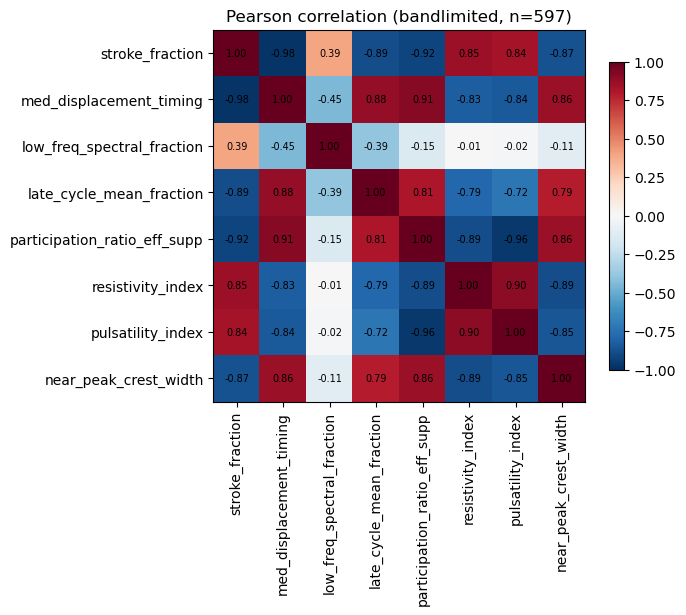

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(REPRESENTATIONS), figsize=(6 * len(REPRESENTATIONS), 5))
axes = np.atleast_1d(axes)
for ax, representation in zip(axes, REPRESENTATIONS):
    corr = correlations[representation]["pearson"]
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(metric_cols)))
    ax.set_xticklabels(metric_cols, rotation=90)
    ax.set_yticks(range(len(metric_cols)))
    ax.set_yticklabels(metric_cols)
    ax.set_title(f"Pearson correlation ({representation}, n={correlations[representation]['n']})")
    for i in range(len(metric_cols)):
        for j in range(len(metric_cols)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()


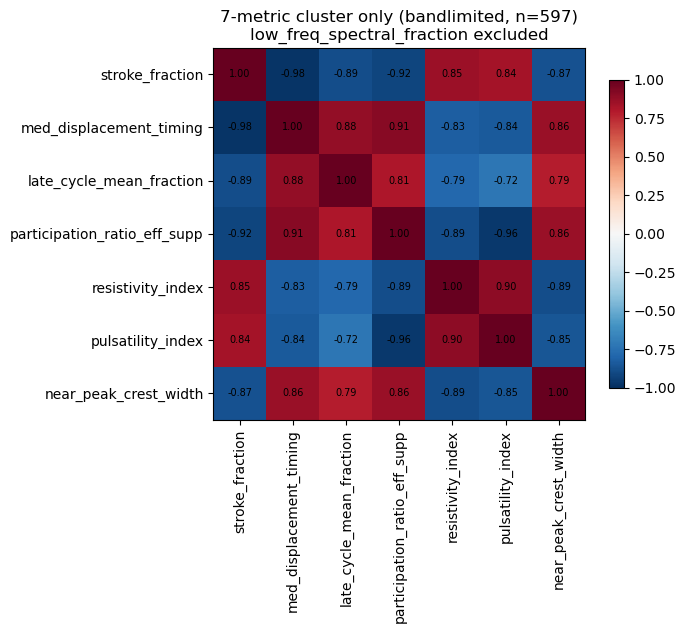

bandlimited: min |r| = 0.72, median |r| = 0.86, max |r| = 0.98


In [7]:
cluster_cols = [m for m in metric_cols if m != "low_freq_spectral_fraction"]

fig, axes = plt.subplots(1, len(REPRESENTATIONS), figsize=(6 * len(REPRESENTATIONS), 5))
axes = np.atleast_1d(axes)
for ax, representation in zip(axes, REPRESENTATIONS):
    corr = correlations[representation]["pearson"].loc[cluster_cols, cluster_cols]
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(cluster_cols)))
    ax.set_xticklabels(cluster_cols, rotation=90)
    ax.set_yticks(range(len(cluster_cols)))
    ax.set_yticklabels(cluster_cols)
    ax.set_title(
        f"7-metric cluster only ({representation}, n={correlations[representation]['n']})\n"
        "low_freq_spectral_fraction excluded"
    )
    for i in range(len(cluster_cols)):
        for j in range(len(cluster_cols)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

for representation in REPRESENTATIONS:
    cluster_r = correlations[representation]["pearson"].loc[cluster_cols, cluster_cols].values
    off_diag = cluster_r[~np.eye(len(cluster_cols), dtype=bool)]
    print(f"{representation}: min |r| = {abs(off_diag).min():.2f}, median |r| = {np.median(abs(off_diag)):.2f}, max |r| = {abs(off_diag).max():.2f}")

In [8]:
cluster_cols = [m for m in metric_cols if m != "low_freq_spectral_fraction"]

cohort_rows = []
for (cohort, group), sub in wide_df.groupby(["cohort", "group"]):
    for representation in REPRESENTATIONS:
        subset = sub.loc[sub["representation"] == representation, cluster_cols + ["low_freq_spectral_fraction"]].dropna()
        n = len(subset)
        if n < 3:
            continue
        cluster_corr = subset[cluster_cols].corr(method="pearson").values
        off_diag = cluster_corr[~np.eye(len(cluster_cols), dtype=bool)]
        spectral_corr = subset[cluster_cols].corrwith(subset["low_freq_spectral_fraction"])
        cohort_rows.append({
            "cohort": cohort,
            "group": group,
            "representation": representation,
            "n": n,
            "cluster_median_abs_r": np.median(np.abs(off_diag)),
            "cluster_min_abs_r": np.abs(off_diag).min(),
            "cluster_max_abs_r": np.abs(off_diag).max(),
            "spectral_mean_abs_r": spectral_corr.abs().mean(),
        })

cohort_corr_df = pd.DataFrame(cohort_rows).sort_values(["n"], ascending=False).reset_index(drop=True)
pd.set_option("display.max_rows", None)
cohort_corr_df.round(2)

,cohort,group,representation,n,cluster_median_abs_r,cluster_min_abs_r,cluster_max_abs_r,spectral_mean_abs_r
0,POAG_vs_CTRL,CTRL,bandlimited,260,0.79,0.52,0.97,0.24
1,POAG_vs_CTRL,POAG,bandlimited,241,0.89,0.74,0.99,0.24
2,GLONGI_select,before,bandlimited,15,0.95,0.64,1.00,0.51
3,alternate_pressure,ctrl,bandlimited,13,0.98,0.95,1.00,0.15
4,alternate_pressure,pressure,bandlimited,13,0.94,0.80,0.99,0.34
5,GLONGI_select,after,bandlimited,12,0.98,0.93,1.00,0.65
6,251219_BOM0753_no_BL2,F,bandlimited,10,0.97,0.95,1.00,0.34
7,251219_BOM0753_no_BL2,BL,bandlimited,7,0.97,0.91,0.99,0.67
8,260609_BOM0753 Valsalva,BL,bandlimited,6,0.98,0.88,1.00,0.91
9,260609_GUJ Valsalva,Valsalva,bandlimited,6,0.96,0.87,0.99,0.53


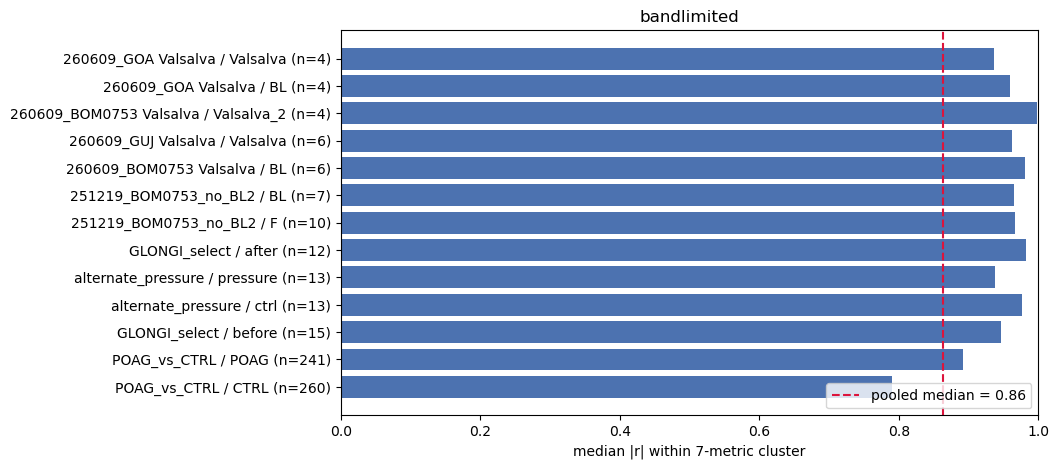

In [9]:
pooled_median = {
    representation: np.median(np.abs(
        correlations[representation]["pearson"].loc[cluster_cols, cluster_cols].values[
            ~np.eye(len(cluster_cols), dtype=bool)
        ]
    ))
    for representation in REPRESENTATIONS
}

fig, axes = plt.subplots(1, len(REPRESENTATIONS), figsize=(9 * len(REPRESENTATIONS), 5), sharey=True)
axes = np.atleast_1d(axes)
for ax, representation in zip(axes, REPRESENTATIONS):
    sub = cohort_corr_df[cohort_corr_df["representation"] == representation].copy()
    labels = sub["cohort"] + " / " + sub["group"] + " (n=" + sub["n"].astype(str) + ")"
    ax.barh(labels, sub["cluster_median_abs_r"], color="#4C72B0")
    ax.axvline(pooled_median[representation], color="crimson", linestyle="--", label=f"pooled median = {pooled_median[representation]:.2f}")
    ax.set_xlim(0, 1)
    ax.set_xlabel("median |r| within 7-metric cluster")
    ax.set_title(f"{representation}")
    ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [10]:
pca_summary = {}
for representation in REPRESENTATIONS:
    corr = correlations[representation]["pearson"].loc[cluster_cols, cluster_cols].values
    eigvals, eigvecs = np.linalg.eigh(corr)
    order = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    explained = eigvals / eigvals.sum()
    pca_summary[representation] = {"eigvals": eigvals, "eigvecs": eigvecs, "explained": explained}
    print(f"--- {representation} (n={correlations[representation]['n']}) ---")
    print("eigenvalues:", np.round(eigvals, 2))
    print("explained variance ratio:", np.round(explained, 3))
    print("cumulative:", np.round(np.cumsum(explained), 3))
    print()

--- bandlimited (n=597) ---
eigenvalues: [6.18 0.37 0.19 0.14 0.08 0.03 0.01]
explained variance ratio: [0.883 0.053 0.028 0.02  0.012 0.004 0.001]
cumulative: [0.883 0.936 0.964 0.984 0.995 0.999 1.   ]



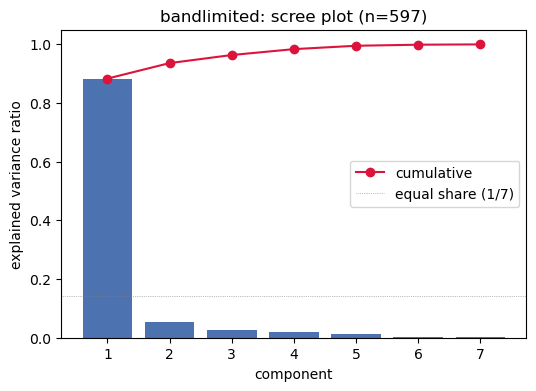

In [11]:
fig, axes = plt.subplots(1, len(REPRESENTATIONS), figsize=(6 * len(REPRESENTATIONS), 4), sharey=True)
axes = np.atleast_1d(axes)
for ax, representation in zip(axes, REPRESENTATIONS):
    explained = pca_summary[representation]["explained"]
    ax.bar(range(1, len(explained) + 1), explained, color="#4C72B0")
    ax.plot(range(1, len(explained) + 1), np.cumsum(explained), color="crimson", marker="o", label="cumulative")
    ax.set_xticks(range(1, len(explained) + 1))
    ax.set_xlabel("component")
    ax.set_ylabel("explained variance ratio")
    ax.set_title(f"{representation}: scree plot (n={correlations[representation]['n']})")
    ax.axhline(1 / len(cluster_cols), color="gray", linewidth=0.5, linestyle=":", label="equal share (1/7)")
    ax.legend()
plt.tight_layout()
plt.show()

In [12]:
loadings_rows = []
for representation in REPRESENTATIONS:
    eigvecs = pca_summary[representation]["eigvecs"]
    for pc in range(2):
        for i, metric in enumerate(cluster_cols):
            loadings_rows.append({
                "representation": representation,
                "component": f"PC{pc+1}",
                "metric": metric,
                "domain": metric_to_domain[metric],
                "loading": eigvecs[i, pc],
            })
loadings_df = pd.DataFrame(loadings_rows)
loadings_wide = loadings_df.pivot_table(
    index=["metric", "domain"], columns=["representation", "component"], values="loading"
)
loadings_wide = loadings_wide.reindex(cluster_cols, level="metric")
loadings_wide.round(2)

representation                           bandlimited      
component                                        PC1   PC2
metric                       domain                       
stroke_fraction              timing            -0.39  0.29
med_displacement_timing      timing             0.39 -0.31
late_cycle_mean_fraction     persistence        0.36 -0.62
participation_ratio_eff_supp persistence        0.39  0.21
resistivity_index            pulsatility       -0.38 -0.32
pulsatility_index            pulsatility       -0.37 -0.51
near_peak_crest_width        persistence        0.37  0.16

In [13]:
n_features = len(cluster_cols)
cohort_pca_rows = []
skipped = []
for (cohort, group), sub in wide_df.groupby(["cohort", "group"]):
    for representation in REPRESENTATIONS:
        subset = sub.loc[sub["representation"] == representation, cluster_cols].dropna()
        n = len(subset)
        if n < n_features + 2:
            skipped.append((cohort, group, representation, n))
            continue
        corr = subset.corr(method="pearson").values
        eigvals = np.linalg.eigvalsh(corr)[::-1]
        explained = eigvals / eigvals.sum()
        cohort_pca_rows.append({
            "cohort": cohort,
            "group": group,
            "representation": representation,
            "n": n,
            "pc1_explained": explained[0],
            "pc1_pc2_explained": explained[:2].sum(),
            # need >= 2x as many rows as metrics for the covariance estimate to be reasonably stable
            "reliable_n": n >= 2 * n_features,
        })

cohort_pca_df = pd.DataFrame(cohort_pca_rows).sort_values("n", ascending=False).reset_index(drop=True)
print(f"skipped {len(skipped)} cohort/group/representation combos with n < {n_features + 2} (too few rows for a 7-feature covariance estimate):")
for s in skipped:
    print(" ", s)
cohort_pca_df.round(2)

skipped 7 cohort/group/representation combos with n < 9 (too few rows for a 7-feature covariance estimate):
  ('251219_BOM0753_no_BL2', 'BL', 'bandlimited', 7)
  ('260609_BOM0753 Valsalva', 'BL', 'bandlimited', 6)
  ('260609_BOM0753 Valsalva', 'Valsalva_2', 'bandlimited', 4)
  ('260609_GOA Valsalva', 'BL', 'bandlimited', 4)
  ('260609_GOA Valsalva', 'Valsalva', 'bandlimited', 4)
  ('260609_GUJ Valsalva', 'BL', 'bandlimited', 2)
  ('260609_GUJ Valsalva', 'Valsalva', 'bandlimited', 6)


,cohort,group,representation,n,pc1_explained,pc1_pc2_explained,reliable_n
0,POAG_vs_CTRL,CTRL,bandlimited,260,0.82,0.91,True
1,POAG_vs_CTRL,POAG,bandlimited,241,0.90,0.95,True
2,GLONGI_select,before,bandlimited,15,0.91,0.98,True
3,alternate_pressure,ctrl,bandlimited,13,0.98,0.99,False
4,alternate_pressure,pressure,bandlimited,13,0.94,0.97,False
5,GLONGI_select,after,bandlimited,12,0.98,0.99,False
6,251219_BOM0753_no_BL2,F,bandlimited,10,0.97,0.99,False


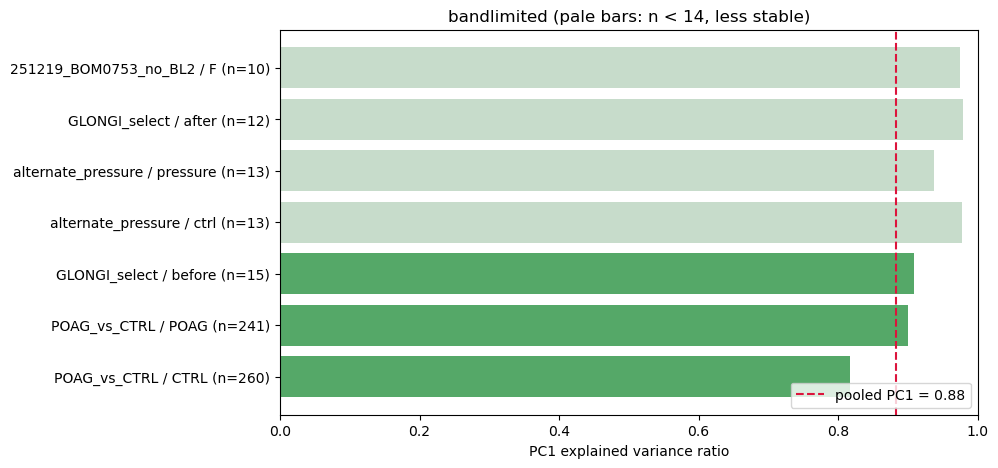

In [14]:
pooled_pc1 = {r: pca_summary[r]["explained"][0] for r in REPRESENTATIONS}

fig, axes = plt.subplots(1, len(REPRESENTATIONS), figsize=(9 * len(REPRESENTATIONS), 5), sharey=True)
axes = np.atleast_1d(axes)
for ax, representation in zip(axes, REPRESENTATIONS):
    sub = cohort_pca_df[cohort_pca_df["representation"] == representation].copy()
    labels = sub["cohort"] + " / " + sub["group"] + " (n=" + sub["n"].astype(str) + ")"
    colors = ["#55A868" if r else "#C7DCCB" for r in sub["reliable_n"]]
    ax.barh(labels, sub["pc1_explained"], color=colors)
    ax.axvline(pooled_pc1[representation], color="crimson", linestyle="--", label=f"pooled PC1 = {pooled_pc1[representation]:.2f}")
    ax.set_xlim(0, 1)
    ax.set_xlabel("PC1 explained variance ratio")
    ax.set_title(f"{representation} (pale bars: n < {2 * n_features}, less stable)")
    ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
from postprocess.composite_scoring.scoring import _severity

def compute_scores(row):
    severities = {
        metric_key: _severity(row[metric_key], METRICS[metric_key], PLOT_VESSEL_TYPE)
        for metric_key in metric_cols
    }
    domain_max_score = sum(
        domain.weight * max(severities[m] for m in domain.metrics) for domain in DOMAINS.values()
    )
    n_m = len(metric_cols)
    paper_sum_score = (10 / n_m) * sum(severities.values())
    return pd.Series({"current_max_score": domain_max_score, "paper_sum_score": paper_sum_score})


scored_df = wide_df.dropna(subset=metric_cols).copy()
scored_df[["current_max_score", "paper_sum_score"]] = scored_df.apply(compute_scores, axis=1)

for representation in REPRESENTATIONS:
    sub = scored_df[scored_df["representation"] == representation]
    r = sub["current_max_score"].corr(sub["paper_sum_score"])
    rs = sub["current_max_score"].corr(sub["paper_sum_score"], method="spearman")
    print(f"{representation}: pearson r={r:.3f}, spearman rho={rs:.3f}, n={len(sub)}")

bandlimited: pearson r=0.989, spearman rho=0.993, n=597


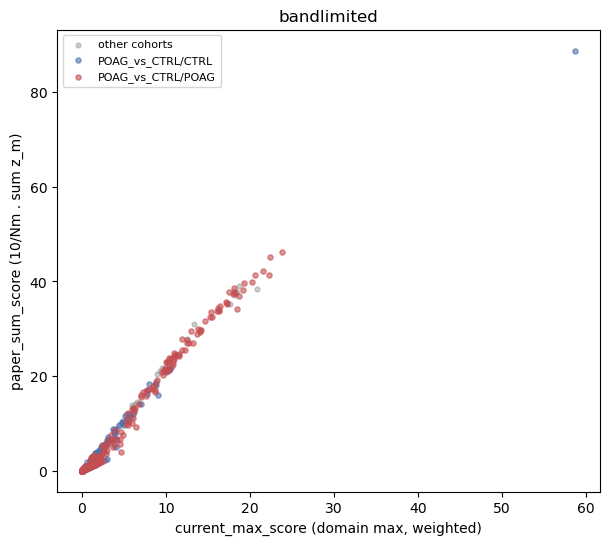

In [16]:
fig, axes = plt.subplots(1, len(REPRESENTATIONS), figsize=(7 * len(REPRESENTATIONS), 6))
axes = np.atleast_1d(axes)
for ax, representation in zip(axes, REPRESENTATIONS):
    sub = scored_df[scored_df["representation"] == representation]
    is_poag = sub["cohort"] == "POAG_vs_CTRL"
    ax.scatter(
        sub.loc[~is_poag, "current_max_score"], sub.loc[~is_poag, "paper_sum_score"],
        s=12, alpha=0.5, color="#999999", label="other cohorts",
    )
    for grp, color in [("CTRL", "#4C72B0"), ("POAG", "#C44E52")]:
        m = is_poag & (sub["group"] == grp)
        ax.scatter(sub.loc[m, "current_max_score"], sub.loc[m, "paper_sum_score"], s=14, alpha=0.6, color=color, label=f"POAG_vs_CTRL/{grp}")
    ax.set_xlabel("current_max_score (domain max, weighted)")
    ax.set_ylabel("paper_sum_score (10/Nm . sum z_m)")
    ax.set_title(f"{representation}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import roc_auc_score

poag_ctrl = scored_df[scored_df["cohort"] == "POAG_vs_CTRL"].copy()
poag_ctrl["label"] = (poag_ctrl["group"] == "POAG").astype(int)

auc_rows = []
for representation in REPRESENTATIONS:
    sub = poag_ctrl[poag_ctrl["representation"] == representation]
    for score_col in ["current_max_score", "paper_sum_score"]:
        auc = roc_auc_score(sub["label"], sub[score_col])
        auc_rows.append({"representation": representation, "score": score_col, "n": len(sub), "auc": auc})

auc_df = pd.DataFrame(auc_rows)
auc_df.round(3)

,representation,score,n,auc
0,bandlimited,current_max_score,501,0.711
1,bandlimited,paper_sum_score,501,0.707


bandlimited: best single metric = low_freq_spectral_fraction (AUC=0.669)


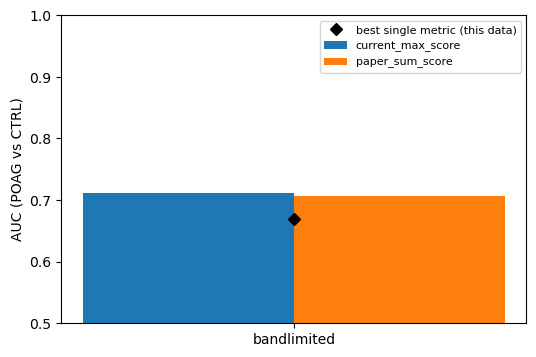

In [ ]:
best_single = {}
for representation in REPRESENTATIONS:
    sub = poag_ctrl[poag_ctrl["representation"] == representation]
    per_metric_auc = {}
    for metric_key in metric_cols:
        sev = sub.apply(lambda r: _severity(r[metric_key], METRICS[metric_key], PLOT_VESSEL_TYPE), axis=1)
        per_metric_auc[metric_key] = roc_auc_score(sub["label"], sev)
    best_metric = max(per_metric_auc, key=per_metric_auc.get)
    best_single[representation] = (best_metric, per_metric_auc[best_metric])
    print(f"{representation}: best single metric = {best_metric} (AUC={per_metric_auc[best_metric]:.3f})")

fig, ax = plt.subplots(figsize=(6, 4))
width = 0.35
reps = list(REPRESENTATIONS)
x = np.arange(len(reps))
for i, score_col in enumerate(["current_max_score", "paper_sum_score"]):
    vals = [auc_df[(auc_df.representation == r) & (auc_df.score == score_col)]["auc"].iloc[0] for r in reps]
    ax.bar(x + (i - 0.5) * width, vals, width, label=score_col)
best_vals = [best_single[r][1] for r in reps]
ax.plot(x, best_vals, color="black", marker="D", linestyle="none", label="best single metric (this data)")
ax.set_xticks(x)
ax.set_xticklabels(reps)
ax.set_ylabel("AUC (POAG vs CTRL)")
ax.set_ylim(0.5, 1.0)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
per_metric_auc = {}
for metric_key in metric_cols:
    sev = poag_ctrl.apply(lambda r: _severity(r[metric_key], METRICS[metric_key], PLOT_VESSEL_TYPE), axis=1)
    per_metric_auc[metric_key] = roc_auc_score(poag_ctrl["label"], sev)

auc_series = pd.Series(per_metric_auc).sort_values(ascending=False)
print("=== per-metric AUC, POAG vs CTRL (bandlimited) ===")
print(auc_series.round(3))

best_cluster_metric = auc_series.loc[cluster_cols].idxmax()
independent_metric = "low_freq_spectral_fraction"
print(f"\nbest cluster-representative metric: {best_cluster_metric} (AUC={auc_series[best_cluster_metric]:.3f})")
print(f"independent metric: {independent_metric} (AUC={auc_series[independent_metric]:.3f})")

=== per-metric AUC, POAG vs CTRL (bandlimited) ===
low_freq_spectral_fraction      0.669
participation_ratio_eff_supp    0.666
late_cycle_mean_fraction        0.660
med_displacement_timing         0.659
near_peak_crest_width           0.652
stroke_fraction                 0.652
resistivity_index               0.642
pulsatility_index               0.630
dtype: float64

best cluster-representative metric: participation_ratio_eff_supp (AUC=0.666)
independent metric: low_freq_spectral_fraction (AUC=0.669)


In [ ]:
reduced_metrics = [best_cluster_metric, independent_metric]


def reduced_score_row(row):
    severities = [_severity(row[m], METRICS[m], PLOT_VESSEL_TYPE) for m in reduced_metrics]
    return (10 / len(reduced_metrics)) * sum(severities)


scored_df["reduced_score"] = scored_df.apply(reduced_score_row, axis=1)
poag_ctrl["reduced_score"] = poag_ctrl.apply(reduced_score_row, axis=1)

auc_reduced = roc_auc_score(poag_ctrl["label"], poag_ctrl["reduced_score"])
auc_current_max = roc_auc_score(poag_ctrl["label"], poag_ctrl["current_max_score"])
auc_paper_sum = roc_auc_score(poag_ctrl["label"], poag_ctrl["paper_sum_score"])

summary = pd.DataFrame([
    {"score": f"reduced_score ({best_cluster_metric} + {independent_metric})", "n_metrics": 2, "auc": auc_reduced},
    {"score": "current_max_score (8 metrics, domain-weighted max)", "n_metrics": 8, "auc": auc_current_max},
    {"score": "paper_sum_score (8 metrics, flat sum)", "n_metrics": 8, "auc": auc_paper_sum},
    {"score": f"best single metric ({independent_metric})", "n_metrics": 1, "auc": auc_series[independent_metric]},
    {"score": f"best cluster metric alone ({best_cluster_metric})", "n_metrics": 1, "auc": auc_series[best_cluster_metric]},
])
summary.round(3)

score,n_metrics,auc
reduced_score (participation_ratio_eff_supp + low_freq_spectral_fraction),2,0.703
"current_max_score (8 metrics, domain-weighted max)",8,0.711
"paper_sum_score (8 metrics, flat sum)",8,0.707
best single metric (low_freq_spectral_fraction),1,0.669
best cluster metric alone (participation_ratio_eff_supp),1,0.666


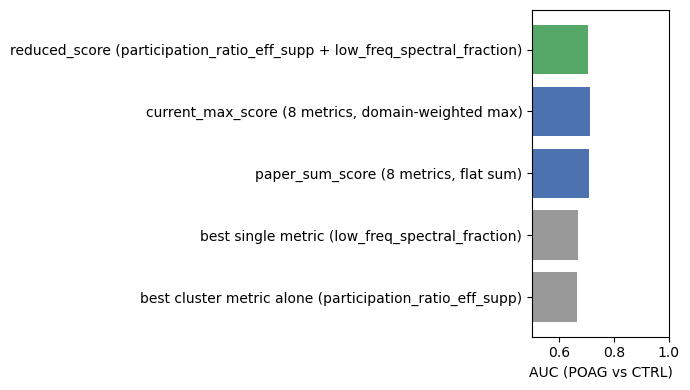

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#55A868", "#4C72B0", "#4C72B0", "#999999", "#999999"]
ax.barh(summary["score"], summary["auc"], color=colors)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel("AUC (POAG vs CTRL)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold

severity_cols = {m: poag_ctrl.apply(lambda r: _severity(r[m], METRICS[m], PLOT_VESSEL_TYPE), axis=1) for m in metric_cols}
sev_df = pd.DataFrame(severity_cols)
y = poag_ctrl["label"].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

fold_rows = []
for fold_i, (train_idx, test_idx) in enumerate(skf.split(sev_df, y), start=1):
    y_train, y_test = y[train_idx], y[test_idx]

    train_auc = {m: roc_auc_score(y_train, sev_df.iloc[train_idx][m]) for m in cluster_cols}
    selected_metric = max(train_auc, key=train_auc.get)

    reduced_test = (10 / 2) * (sev_df.iloc[test_idx][selected_metric] + sev_df.iloc[test_idx][independent_metric])

    fold_rows.append({
        "fold": fold_i,
        "n_test": len(test_idx),
        "selected_metric": selected_metric,
        "reduced_score_auc": roc_auc_score(y_test, reduced_test),
        "current_max_auc": roc_auc_score(y_test, poag_ctrl.iloc[test_idx]["current_max_score"]),
        "paper_sum_auc": roc_auc_score(y_test, poag_ctrl.iloc[test_idx]["paper_sum_score"]),
        "independent_alone_auc": roc_auc_score(y_test, sev_df.iloc[test_idx][independent_metric]),
        "selected_alone_auc": roc_auc_score(y_test, sev_df.iloc[test_idx][selected_metric]),
    })

cv_df_reduced2 = pd.DataFrame(fold_rows)
print("=== per-fold results ===")
print(cv_df_reduced2.round(3).to_string(index=False))
print("\n=== selected metric counts across folds ===")
print(cv_df_reduced2["selected_metric"].value_counts())

=== per-fold results ===
 fold  n_test              selected_metric  reduced_score_auc  current_max_auc  paper_sum_auc  independent_alone_auc  selected_alone_auc
    1     101 participation_ratio_eff_supp              0.742            0.747          0.737                  0.682               0.699
    2     100     late_cycle_mean_fraction              0.642            0.681          0.682                  0.696               0.587
    3     100 participation_ratio_eff_supp              0.730            0.749          0.745                  0.718               0.696
    4     100 participation_ratio_eff_supp              0.702            0.725          0.729                  0.646               0.685
    5     100 participation_ratio_eff_supp              0.656            0.650          0.641                  0.607               0.618

=== selected metric counts across folds ===
selected_metric
participation_ratio_eff_supp    4
late_cycle_mean_fraction        1
Name: count, dtype: int6

In [23]:
summary_cols_reduced2 = ["reduced_score_auc", "current_max_auc", "paper_sum_auc", "independent_alone_auc", "selected_alone_auc"]
cv_summary_reduced2 = cv_df_reduced2[summary_cols_reduced2].agg(["mean", "std"]).T
cv_summary_reduced2.round(3)

,mean,std
reduced_score_auc,0.694,0.044
current_max_auc,0.711,0.043
paper_sum_auc,0.707,0.044
independent_alone_auc,0.670,0.044
selected_alone_auc,0.657,0.051


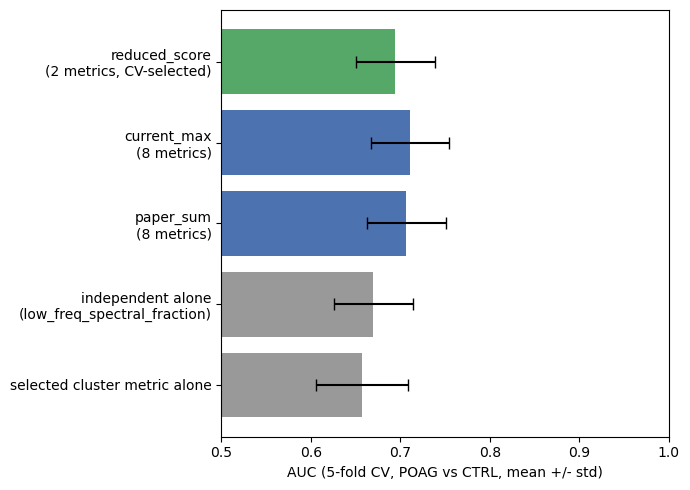

In [24]:
fig, ax = plt.subplots(figsize=(7, 5))
labels = ["reduced_score\n(2 metrics, CV-selected)", "current_max\n(8 metrics)", "paper_sum\n(8 metrics)",
          "independent alone\n(low_freq_spectral_fraction)", "selected cluster metric alone"]
means = cv_summary_reduced2["mean"].values
stds = cv_summary_reduced2["std"].values
colors = ["#55A868", "#4C72B0", "#4C72B0", "#999999", "#999999"]
ax.barh(labels, means, xerr=stds, color=colors, capsize=4)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel("AUC (5-fold CV, POAG vs CTRL, mean +/- std)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
severity_cols = {m: poag_ctrl.apply(lambda r: _severity(r[m], METRICS[m], PLOT_VESSEL_TYPE), axis=1) for m in metric_cols}
sev_df = pd.DataFrame(severity_cols)
y = poag_ctrl["label"].values

hedge_cluster_metrics = ["participation_ratio_eff_supp", "late_cycle_mean_fraction", "med_displacement_timing"]
hedge_panel = hedge_cluster_metrics + [independent_metric]


def score_from_panel(idx, panel):
    n_m = len(panel)
    return (10 / n_m) * sev_df.iloc[idx][panel].sum(axis=1)


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

fold_rows = []
for fold_i, (train_idx, test_idx) in enumerate(skf.split(sev_df, y), start=1):
    y_train, y_test = y[train_idx], y[test_idx]

    # strict 2-metric, re-selected per fold (as before)
    train_auc = {m: roc_auc_score(y_train, sev_df.iloc[train_idx][m]) for m in cluster_cols}
    selected_metric = max(train_auc, key=train_auc.get)
    reduced_2_test = (10 / 2) * (sev_df.iloc[test_idx][selected_metric] + sev_df.iloc[test_idx][independent_metric])

    # hedge panel, fixed, no per-fold selection
    hedge_test = score_from_panel(test_idx, hedge_panel)

    fold_rows.append({
        "fold": fold_i,
        "n_test": len(test_idx),
        "reduced_2_auc": roc_auc_score(y_test, reduced_2_test),
        "hedge_4_auc": roc_auc_score(y_test, hedge_test),
        "current_max_auc": roc_auc_score(y_test, poag_ctrl.iloc[test_idx]["current_max_score"]),
        "paper_sum_auc": roc_auc_score(y_test, poag_ctrl.iloc[test_idx]["paper_sum_score"]),
    })

cv_df_hedge = pd.DataFrame(fold_rows)
print("=== per-fold results ===")
print(cv_df_hedge.round(3).to_string(index=False))

=== per-fold results ===
 fold  n_test  reduced_2_auc  hedge_4_auc  current_max_auc  paper_sum_auc
    1     101          0.742        0.729            0.747          0.737
    2     100          0.642        0.664            0.681          0.682
    3     100          0.730        0.730            0.749          0.745
    4     100          0.702        0.705            0.725          0.729
    5     100          0.656        0.651            0.650          0.641


In [26]:
summary_cols_hedge = ["reduced_2_auc", "hedge_4_auc", "current_max_auc", "paper_sum_auc"]
cv_summary_hedge = cv_df_hedge[summary_cols_hedge].agg(["mean", "std"]).T
cv_summary_hedge.round(3)

,mean,std
reduced_2_auc,0.694,0.044
hedge_4_auc,0.696,0.037
current_max_auc,0.711,0.043
paper_sum_auc,0.707,0.044


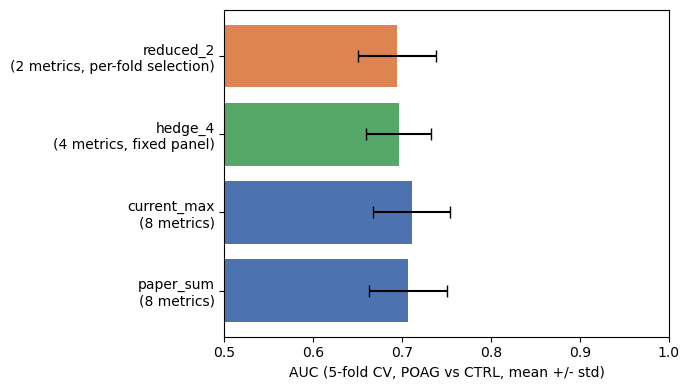

In [27]:
fig, ax = plt.subplots(figsize=(7, 4))
labels = ["reduced_2\n(2 metrics, per-fold selection)", "hedge_4\n(4 metrics, fixed panel)",
          "current_max\n(8 metrics)", "paper_sum\n(8 metrics)"]
means = cv_summary_hedge["mean"].values
stds = cv_summary_hedge["std"].values
colors = ["#DD8452", "#55A868", "#4C72B0", "#4C72B0"]
ax.barh(labels, means, xerr=stds, color=colors, capsize=4)
ax.set_xlim(0.5, 1.0)
ax.set_xlabel("AUC (5-fold CV, POAG vs CTRL, mean +/- std)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
VESSEL_TYPE = "artery"
GROUP_BASE = f"AngioEye/Processing/waveform_shape_metrics/{VESSEL_TYPE}/global/{REPRESENTATIONS[0]}"

poag_dir = DATA_ROOT / "POAG_vs_CTRL" / "POAG"
ctrl_dir = DATA_ROOT / "POAG_vs_CTRL" / "CTRL"
poag_files = [p for p in (processed_path_for(x) for x in sorted(poag_dir.glob("*.h5"))) if p.exists()]
ctrl_files = [p for p in (processed_path_for(x) for x in sorted(ctrl_dir.glob("*.h5"))) if p.exists()]

sample = ctrl_files[0]
candidate_fields = []
with h5py.File(sample, "r") as h5:
    g = h5[GROUP_BASE]
    for k in sorted(g.keys()):
        item = g[k]
        if isinstance(item, h5py.Group):
            continue
        arr = np.asarray(item[()])
        if arr.size <= 4:
            candidate_fields.append((k, "direct"))
    diag = g.get("diagnostics")
    if diag is not None:
        for k in sorted(diag.keys()):
            item = diag[k]
            if isinstance(item, h5py.Group):
                continue
            arr = np.asarray(item[()])
            if arr.size <= 4:
                candidate_fields.append((k, "diagnostics"))

print(f"{len(candidate_fields)} candidate scalar fields discovered (vs {len(metric_cols)} currently used)")
print([name for name, _ in candidate_fields])

52 candidate scalar fields discovered (vs 8 currently used)
['CF', 'Delta_DTI', 'E_LF_over_E_HF', 'E_low', 'E_slope', 'E_total', 'H_LOW_MAX', 'H_MAX', 'N_eff_over_T', 'N_t_over_T', 'PI', 'Q_d_skew', 'Q_d_width', 'Q_t_skew', 'Q_t_width', 'RI', 'R_VTI', 'SF_VTI', 'S_fall', 'S_rise', 'W50_over_T', 'W80_over_T', 'd10_over_D', 'd25_over_D', 'd50_over_D', 'd75_over_D', 'd90_over_D', 'eta_h', 'gamma_t', 'm0', 'mu_t', 'mu_t_over_T', 'sigma_t', 'sigma_t_over_T', 't10_over_T', 't25_over_T', 't50_over_T', 't75_over_T', 't90_over_T', 't_fall_over_T', 't_max_over_T', 't_min_over_T', 't_rise_over_T', 'v_end_over_vbar', 'vend', 'vmax', 'vmean', 'vmin', 'm_50', 'm_80', 'rho_h', 'w_h']


In [ ]:
def finite_scalar(value):
    values = np.asarray(value, dtype=float).ravel()
    values = values[np.isfinite(values)]
    if values.size == 0:
        return None
    return float(values[0])


def extract_all(processed_path):
    out = {}
    with h5py.File(processed_path, "r") as h5:
        source_group = find_pipeline_group(h5, "waveform_shape_metrics")
        if source_group is None:
            return {name: None for name, _ in candidate_fields}
        base = source_group[f"{VESSEL_TYPE}/global/{REPRESENTATIONS[0]}"]
        for name, source in candidate_fields:
            grp = base if source == "direct" else base.get("diagnostics")
            if grp is None or name not in grp:
                out[name] = None
                continue
            out[name] = finite_scalar(grp[name][()])
    return out


screen_rows = []
for label, files in [(1, poag_files), (0, ctrl_files)]:
    for path in files:
        values = extract_all(path)
        values["label"] = label
        values["file"] = path.name
        screen_rows.append(values)

screen_df = pd.DataFrame(screen_rows)
known_metric_names = {m.name for m in METRICS.values()}

screen_results = []
for name, source in candidate_fields:
    sub = screen_df[[name, "label"]].dropna()
    if len(sub) < 20 or sub[name].nunique() < 2:
        continue
    auc_raw = roc_auc_score(sub["label"], sub[name])
    auc_corrected = max(auc_raw, 1 - auc_raw)
    screen_results.append({
        "metric": name, "source": source, "already_used": name in known_metric_names,
        "n": len(sub), "auc_raw": auc_raw, "auc_corrected": auc_corrected,
    })

screen_results_df = pd.DataFrame(screen_results).sort_values("auc_corrected", ascending=False).reset_index(drop=True)
screen_results_df.round(3)

metric,source,already_used,n,auc_raw,auc_corrected
vend,direct,False,501,0.267,0.733
vmin,direct,False,501,0.275,0.725
vmean,direct,False,501,0.281,0.719
Q_d_skew,direct,False,501,0.305,0.695
Q_t_skew,direct,False,501,0.694,0.694
gamma_t,direct,False,501,0.688,0.688
t50_over_T,direct,True,501,0.313,0.687
SF_VTI,direct,True,501,0.687,0.687
v_end_over_vbar,direct,True,501,0.314,0.686
d50_over_D,direct,False,501,0.685,0.685


In [ ]:
rows = []
for group, raw_files in manifest["POAG_vs_CTRL"].items():
    for raw_path in raw_files:
        proc_path = processed_path_for(raw_path)
        if not proc_path.exists():
            continue
        try:
            with h5py.File(raw_path, "r") as h5:
                diameter = finite_scalar(h5["Artery/CrossSections/Diameter/Mean/value"][()])
        except (KeyError, OSError):
            diameter = None
        with h5py.File(proc_path, "r") as h5:
            sg = find_pipeline_group(h5, "waveform_shape_metrics")
            if sg is None:
                continue
            base = sg[f"{PLOT_VESSEL_TYPE}/global/{REPRESENTATIONS[0]}"]
            vend = finite_scalar(base["vend"][()]) if "vend" in base else None
            vmin = finite_scalar(base["vmin"][()]) if "vmin" in base else None
            vmean = finite_scalar(base["vmean"][()]) if "vmean" in base else None
        rows.append({"group": group, "diameter": diameter, "vend": vend, "vmin": vmin, "vmean": vmean,
                      "label": 1 if group == "POAG" else 0})

diam_df = pd.DataFrame(rows).dropna()
print(f"n={len(diam_df)}")
for col in ["vend", "vmin", "vmean"]:
    r = diam_df["diameter"].corr(diam_df[col])
    print(f"corr(diameter, {col}) = {r:.3f}")

auc_diam = roc_auc_score(diam_df["label"], diam_df["diameter"])
print(f"\nAUC(diameter alone, POAG vs CTRL) = {max(auc_diam, 1 - auc_diam):.3f}")

n=463
corr(diameter, vend) = 0.023
corr(diameter, vmin) = -0.024
corr(diameter, vmean) = -0.009

AUC(diameter alone, POAG vs CTRL) = 0.501


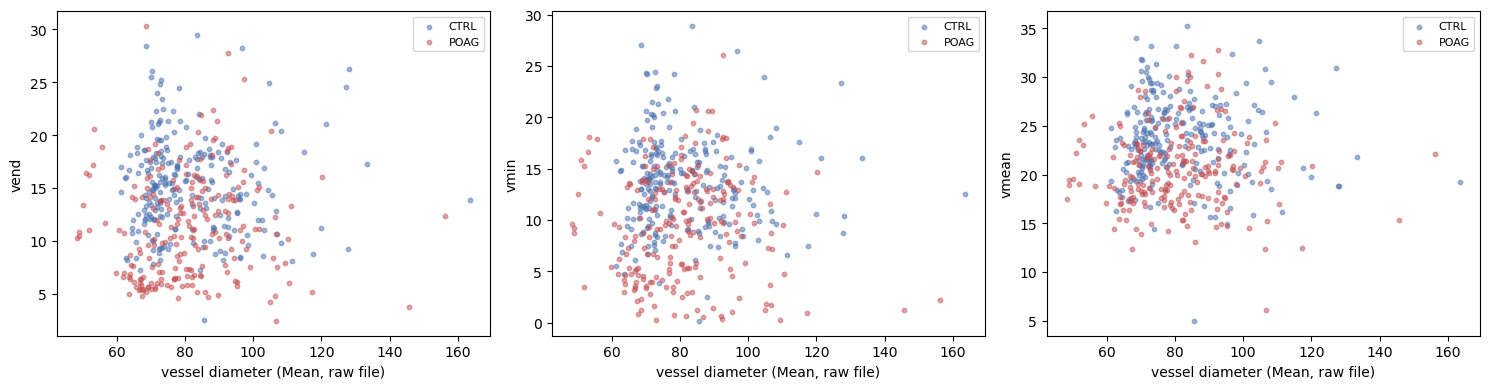

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["vend", "vmin", "vmean"]):
    for grp, color in [("CTRL", "#4C72B0"), ("POAG", "#C44E52")]:
        sub = diam_df[diam_df["group"] == grp]
        ax.scatter(sub["diameter"], sub[col], s=10, alpha=0.5, color=color, label=grp)
    ax.set_xlabel("vessel diameter (Mean, raw file)")
    ax.set_ylabel(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
rows2 = []
for cohort, groups in manifest.items():
    for group, raw_files in groups.items():
        for raw_path in raw_files:
            proc_path = processed_path_for(raw_path)
            if not proc_path.exists():
                continue
            with h5py.File(proc_path, "r") as h5:
                sg = find_pipeline_group(h5, "waveform_shape_metrics")
                if sg is None:
                    continue
                base = sg[f"{PLOT_VESSEL_TYPE}/global/{REPRESENTATIONS[0]}"]
                vals = {}
                for name in ["vend", "vmin", "vmean", "SF_VTI"]:
                    vals[name] = finite_scalar(base[name][()]) if name in base else None
            rows2.append({"cohort": cohort, "group": group, **vals})

cross_df = pd.DataFrame(rows2)
cv_rows = []
for name in ["vend", "vmin", "vmean", "SF_VTI"]:
    grouped = cross_df.groupby("cohort")[name].agg(["mean", "std", "count"]).dropna()
    overall_cv = cross_df[name].std() / abs(cross_df[name].mean())
    between_cohort_cv = grouped["mean"].std() / abs(grouped["mean"].mean())
    cv_rows.append({"metric": name, "overall_cv": overall_cv, "between_cohort_mean_cv": between_cohort_cv})

cross_cohort_cv_df = pd.DataFrame(cv_rows)
cross_cohort_cv_df.round(3)

metric,overall_cv,between_cohort_mean_cv
vend,0.381,0.225
vmin,0.458,0.266
vmean,0.195,0.099
SF_VTI,0.110,0.068


In [ ]:
current_panel = ["participation_ratio_eff_supp", "late_cycle_mean_fraction", "med_displacement_timing", "low_freq_spectral_fraction"]
new_shape_candidates = ["Q_t_skew", "gamma_t", "d50_over_D", "R_VTI", "N_t_over_T"]


def extract_row(processed_path):
    out = {}
    with h5py.File(processed_path, "r") as h5:
        sg = find_pipeline_group(h5, "waveform_shape_metrics")
        if sg is None:
            return {m: None for m in current_panel + new_shape_candidates}
        for m in current_panel:
            metric = METRICS[m]
            paths = metric.derived_paths(PLOT_VESSEL_TYPE, REPRESENTATIONS[0])
            if paths is None:
                raw = read_dataset(sg, metric.path(PLOT_VESSEL_TYPE, REPRESENTATIONS[0]), default=None)
                out[m] = _finite_scalar(raw) if raw is not None else None
            else:
                num = read_dataset(sg, paths[0], default=None)
                den = read_dataset(sg, paths[1], default=None)
                if num is None or den is None:
                    out[m] = None
                else:
                    num = np.asarray(num, dtype=float)
                    den = np.asarray(den, dtype=float)
                    with np.errstate(divide="ignore", invalid="ignore"):
                        ratio = np.where(np.isfinite(den) & (den != 0), num / den, np.nan)
                    out[m] = _finite_scalar(ratio)
        base = sg[f"{PLOT_VESSEL_TYPE}/global/{REPRESENTATIONS[0]}"]
        for m in new_shape_candidates:
            out[m] = _finite_scalar(base[m][()]) if m in base else None
    return out


poag_files_ = [p for p in (processed_path_for(x) for x in sorted((DATA_ROOT / "POAG_vs_CTRL" / "POAG").glob("*.h5"))) if p.exists()]
ctrl_files_ = [p for p in (processed_path_for(x) for x in sorted((DATA_ROOT / "POAG_vs_CTRL" / "CTRL").glob("*.h5"))) if p.exists()]
rows3 = []
for files, group_name in [(poag_files_, "POAG"), (ctrl_files_, "CTRL")]:
    for p in files:
        r = extract_row(p)
        r["group"] = group_name
        rows3.append(r)

candidate_df = pd.DataFrame(rows3).dropna()
all_cols = current_panel + new_shape_candidates
new_corr = candidate_df[all_cols].corr(method="pearson")
print("n =", len(candidate_df))
print("\n=== max |r| of each new candidate against the current panel ===")
for nc in new_shape_candidates:
    vs_panel = new_corr.loc[nc, current_panel].abs()
    print(f"{nc}: max |r|={vs_panel.max():.2f} (vs {vs_panel.idxmax()}), mean |r|={vs_panel.mean():.2f}")

n = 501

=== max |r| of each new candidate against the current panel ===
Q_t_skew: max |r|=0.99 (vs med_displacement_timing), mean |r|=0.80
gamma_t: max |r|=0.97 (vs med_displacement_timing), mean |r|=0.80
d50_over_D: max |r|=0.96 (vs med_displacement_timing), mean |r|=0.80
R_VTI: max |r|=0.94 (vs med_displacement_timing), mean |r|=0.78
N_t_over_T: max |r|=0.99 (vs participation_ratio_eff_supp), mean |r|=0.68


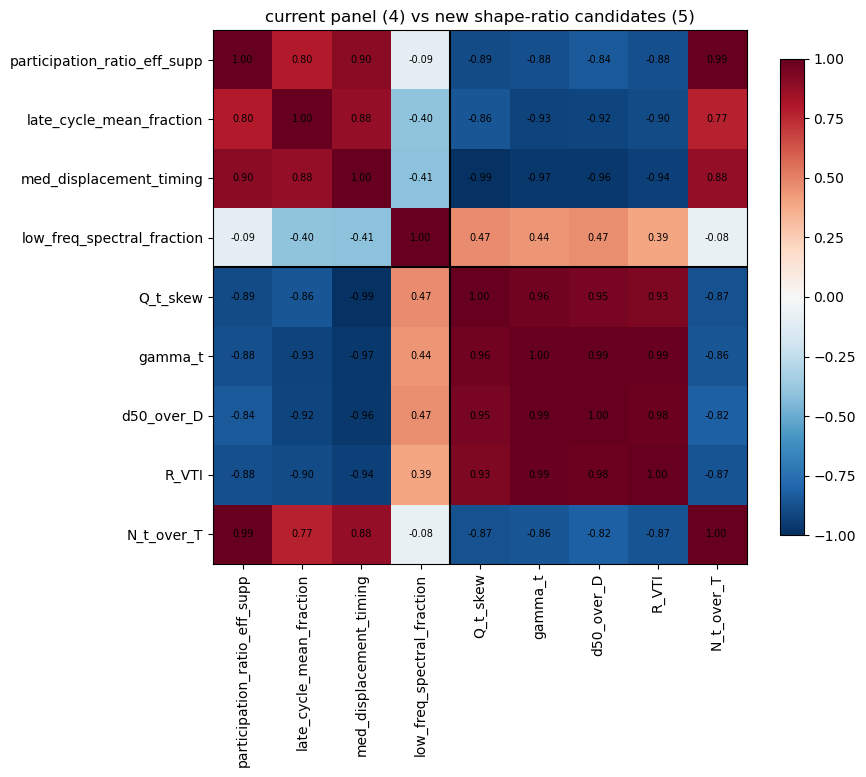

In [34]:
all_cols = current_panel + new_shape_candidates
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(new_corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(all_cols)))
ax.set_xticklabels(all_cols, rotation=90)
ax.set_yticks(range(len(all_cols)))
ax.set_yticklabels(all_cols)
for i in range(len(all_cols)):
    for j in range(len(all_cols)):
        ax.text(j, i, f"{new_corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax.axhline(len(current_panel) - 0.5, color="black", linewidth=1.5)
ax.axvline(len(current_panel) - 0.5, color="black", linewidth=1.5)
ax.set_title("current panel (4) vs new shape-ratio candidates (5)")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import mannwhitneyu


def mannwhitney_p_value(control_values, pathology_values):
    control_values = np.asarray(control_values, dtype=float)
    pathology_values = np.asarray(pathology_values, dtype=float)
    control_values = control_values[np.isfinite(control_values)]
    pathology_values = pathology_values[np.isfinite(pathology_values)]
    if control_values.size == 0 or pathology_values.size == 0:
        return float("nan")
    try:
        result = mannwhitneyu(control_values, pathology_values, alternative="two-sided", method="auto")
        return float(result.pvalue)
    except ValueError:
        return float("nan")


panel_pvalue_rows = []
for m in metric_cols:
    x0 = poag_ctrl.loc[poag_ctrl["group"] == "CTRL", m]
    x1 = poag_ctrl.loc[poag_ctrl["group"] == "POAG", m]
    panel_pvalue_rows.append({
        "metric": m,
        "auc_severity": auc_series[m],
        "p_value_mannwhitney": mannwhitney_p_value(x0, x1),
    })

panel_pvalue_df = pd.DataFrame(panel_pvalue_rows).sort_values("p_value_mannwhitney").reset_index(drop=True)
panel_pvalue_df

metric,auc_severity,p_value_mannwhitney
med_displacement_timing,0.659272,4.064629e-13
stroke_fraction,0.652099,4.293244e-13
late_cycle_mean_fraction,0.659807,5.316648e-13
participation_ratio_eff_supp,0.665560,3.372850e-12
resistivity_index,0.642004,2.650809e-11
pulsatility_index,0.630298,3.109310e-11
low_freq_spectral_fraction,0.669215,3.352753e-11
near_peak_crest_width,0.652107,1.508574e-10


In [ ]:
poag_ctrl["hedge_score"] = (10 / len(hedge_panel)) * sev_df[hedge_panel].sum(axis=1)

score_pvalue_rows = []
for col in ["current_max_score", "paper_sum_score", "reduced_score", "hedge_score"]:
    x0 = poag_ctrl.loc[poag_ctrl["group"] == "CTRL", col]
    x1 = poag_ctrl.loc[poag_ctrl["group"] == "POAG", col]
    score_pvalue_rows.append({
        "score": col,
        "auc": roc_auc_score(poag_ctrl["label"], poag_ctrl[col]),
        "p_value_mannwhitney": mannwhitney_p_value(x0, x1),
    })

score_pvalue_df = pd.DataFrame(score_pvalue_rows)
score_pvalue_df

score,auc,p_value_mannwhitney
current_max_score,0.711203,2.183084e-16
paper_sum_score,0.707158,7.995269e-16
reduced_score,0.702665,2.872311e-15
hedge_score,0.697111,1.640162e-14


In [ ]:
screen_pvalues = []
for name, source in candidate_fields:
    sub = screen_df[[name, "label"]].dropna()
    if len(sub) < 20 or sub[name].nunique() < 2:
        continue
    x0 = sub.loc[sub["label"] == 0, name]
    x1 = sub.loc[sub["label"] == 1, name]
    screen_pvalues.append({"metric": name, "p_value_mannwhitney": mannwhitney_p_value(x0, x1)})

screen_pvalue_df = pd.DataFrame(screen_pvalues)
screen_results_df = screen_results_df.merge(screen_pvalue_df, on="metric", how="left")
screen_results_df.sort_values("auc_corrected", ascending=False).reset_index(drop=True)

metric,source,already_used,n,auc_raw,auc_corrected,p_value_mannwhitney
vend,direct,False,501,0.266869,0.733131,1.841042e-19
vmin,direct,False,501,0.275407,0.724593,3.564211e-18
vmean,direct,False,501,0.281487,0.718513,2.753408e-17
Q_d_skew,direct,False,501,0.305330,0.694670,4.928257e-14
Q_t_skew,direct,False,501,0.694159,0.694159,5.732983e-14
gamma_t,direct,False,501,0.687887,0.687887,3.560352e-13
t50_over_T,direct,True,501,0.312576,0.687424,4.064629e-13
SF_VTI,direct,True,501,0.687233,0.687233,4.293244e-13
v_end_over_vbar,direct,True,501,0.313517,0.686483,5.316648e-13
d50_over_D,direct,False,501,0.684775,0.684775,8.623504e-13
